In [1]:
pip install tensorflow

Note: you may need to restart the kernel to use updated packages.


In [2]:
pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


In [3]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.utils import image_dataset_from_directory
from tensorflow import keras
# from tensorflow.keras.models import Sequential
from tensorflow.keras import layers, models
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
import matplotlib.pyplot as plt 

2026-05-23 12:43:39.534897: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1779540219.743075      16 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779540219.806480      16 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1779540220.283958      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779540220.284022      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779540220.284026      16 computation_placer.cc:177] computation placer alr

In [4]:
dataset_directory='/kaggle/input/datasets/anthonytherrien/dog-vs-cat/animals'
train_dataset =image_dataset_from_directory(
    dataset_directory ,
    validation_split = 0.2,
    subset= "training",
    seed = 123,
    image_size =(180,180),
    batch_size= 32,
    
)


Found 1000 files belonging to 2 classes.
Using 800 files for training.


2026-05-23 12:44:07.958000: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [5]:
test_dataset=image_dataset_from_directory(
     dataset_directory ,
    validation_split = 0.2,
    subset= "validation",
    seed = 123,
    image_size =(180,180),
    batch_size= 32
)

Found 1000 files belonging to 2 classes.
Using 200 files for validation.


In [6]:
for X_batch, y_batch in train_dataset.take(1):
    print("X_train batch shape (Images):", X_batch.shape)  
    print("y_train batch shape (Labels):", y_batch.shape)  
    break

X_train batch shape (Images): (32, 180, 180, 3)
y_train batch shape (Labels): (32,)


In [7]:
# print(X_batch)
# print(y_batch)

In [8]:
# print(X_test)
# print(y_test)

In [9]:
X_test=[]
y_test=[]
for images , labels in test_dataset:
    X_test.append(images.numpy())
    y_test.append(labels.numpy())
    # print(X_test[0])
    # print(X_test[0:10])
    # print(y_test[0:10]) kaggle got stuck after printing list
    

In [10]:
X_test = np.concatenate(X_test, axis=0)
y_test = np.concatenate(y_test, axis=0)

In [11]:
# our data sets are
# test_dataset
# train_dataset
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
# normalize the data
model =Sequential([
    # 1. Changed to layers.Rescaling and added the missing closing parenthesis ')' at the end of the line
    layers.Rescaling(1.0/255, input_shape=(180, 180, 3)), 
    
    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(2, activation='softmax')
])
# print(model) this will show if our model is build or not

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/tf_data_layer.py:19: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [12]:
model.compile(
    optimizer = 'adam',
    loss ='sparse_categorical_crossentropy',
    metrics = ['accuracy']
)
# print(model) last one was sequential 3, and this is sequential 4, and built is true

In [13]:
history = model.fit(
    train_dataset,
    validation_data= test_dataset,
    epochs= 10
)

Epoch 1/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 19s 698ms/step - accuracy: 0.4829 - loss: 10.4695 - val_accuracy: 0.5450 - val_loss: 0.6841
Epoch 2/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 20s 673ms/step - accuracy: 0.5649 - loss: 0.6787 - val_accuracy: 0.6300 - val_loss: 0.6081
Epoch 3/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 17s 684ms/step - accuracy: 0.6607 - loss: 0.5721 - val_accuracy: 0.8550 - val_loss: 0.4766
Epoch 4/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 17s 684ms/step - accuracy: 0.8193 - loss: 0.4739 - val_accuracy: 0.7700 - val_loss: 0.4763
Epoch 5/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 21s 690ms/step - accuracy: 0.8166 - loss: 0.4240 - val_accuracy: 0.9150 - val_loss: 0.3749
Epoch 6/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 17s 684ms/step - accuracy: 0.8376 - loss: 0.3726 - val_accuracy: 0.9200 - val_loss: 0.3188
Epoch 7/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 21s 692ms/step - accuracy: 0.8906 - loss: 0.3596 - val_accuracy: 0.9000 - val_loss: 0.3307
Epoch 8/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 17s 687ms/step - accuracy: 0.9102 - loss: 0.2890 - val_acc

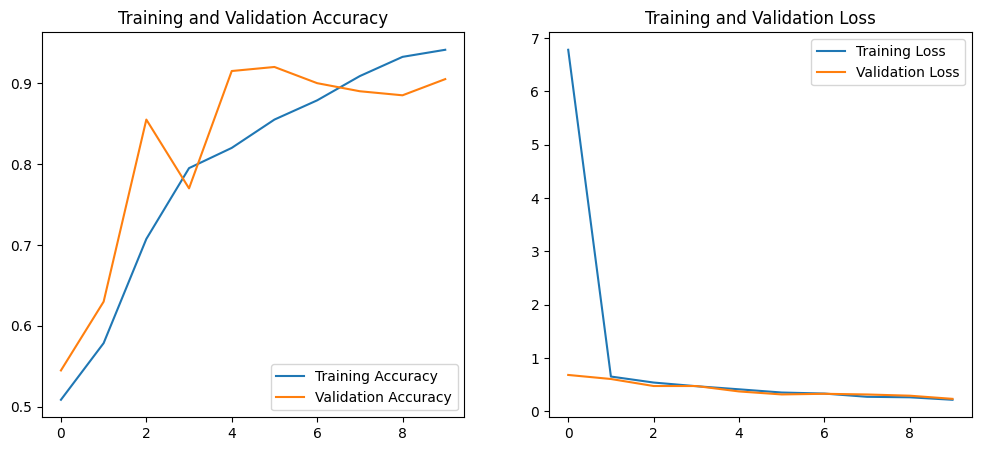

In [14]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(len(acc))

plt.figure(figsize=(12, 5))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

In [15]:
test_loss, test_accuracy = model.evaluate(test_dataset)
print(f"Test Data Par Loss: {test_loss:.4f}")
print(f"Test Data Par Accuracy: {test_accuracy * 100:.2f}%")

7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 189ms/step - accuracy: 0.8952 - loss: 0.2379
Test Data Par Loss: 0.2360
Test Data Par Accuracy: 90.50%


In [16]:
img_path ='/kaggle/input/datasets/anthonytherrien/dog-vs-cat/animals/dog/00528-3846168690.png'
img = tf.keras.utils.load_img(img_path , target_size=(180,180))
img_array = tf.keras.utils.img_to_array(img)
img_array = tf.expand_dims(img_array,0)
predictions = model.predict(img_array)
score = predictions[0]

class_names =['Cat' , 'Dog']
predicted_class = class_names[np.argmax(score)]
confidence = 100* np.max(score)
print(f"According to the model the picture is '{predicted_class}'.")
print(f"Model is  {confidence:.2f}% confident on the result.")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
According to the model the picture is 'Dog'.
Model is  96.16% confident on the result.


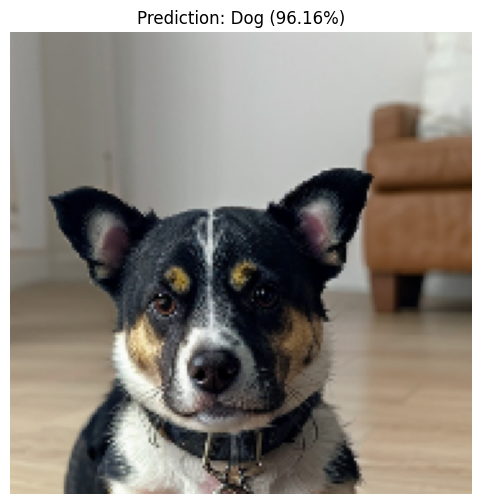

In [17]:
plt.figure(figsize = (6,6))
plt.imshow(img)
plt.title(f"Prediction: {predicted_class} ({confidence:.2f}%)")
plt.axis("off")
plt.show()